# NW SSc Cohort — Exploratory Data Analysis

Cohort-level exploration of the synthetic systemic sclerosis (SSc) dataset:
~1,500 Registry patients plus 4 healthy Control Subjects, spanning
demographics, disease classification, and longitudinal clinical/molecular
measurements. Domain vocabulary (Subject, Cohort, Registry, Observation,
etc.) is defined in [`CONTEXT.md`](../CONTEXT.md); full data-quality findings
live in [`docs/qc_report.md`](../docs/qc_report.md) and
[`docs/presentation-notes.md`](../docs/presentation-notes.md).

This notebook reads exclusively through `data.access` — the same read layer
the Streamlit app uses — against the encrypted-at-rest SQLite store built
from the raw CSVs (`data/data_v3/`). It never re-parses those CSVs itself, so
the numbers here can't silently diverge from what the app shows. Where a
finding below has a QC check purpose-built for it in `data.qc`, that check
is called directly rather than re-derived by hand. Running the first cell
rebuilds the store fresh from the committed CSVs, so this notebook always
reflects their current contents.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402
import seaborn as sns  # noqa: E402

from data.access import (  # noqa: E402
    get_subject_record,
    get_variable,
    list_subjects,
    table_coverage,
)
from data.qc import check_constant_value_across_visits  # noqa: E402
from data.store import build_encrypted_store, open_store  # noqa: E402

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

build_encrypted_store()
conn = open_store()

## Cohort overview

Every Subject belongs to one of two Cohorts: `ssc_patient` (a Registry
member — has `demographics`/`ssc_subtype` rows) or `control` (a healthy
Control Subject, never a Registry member). `list_subjects` returns the full
roster with this split already resolved.

cohort
ssc_patient    1500
control           4
Name: count, dtype: int64


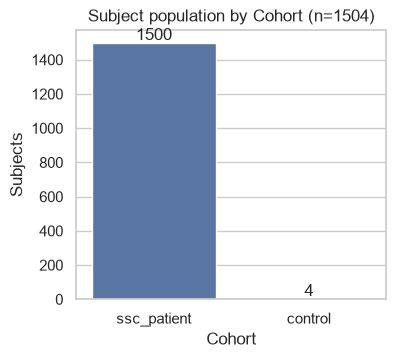

In [2]:
subjects = list_subjects(conn)
cohort_counts = subjects["cohort"].value_counts()
print(cohort_counts)

fig, ax = plt.subplots(figsize=(4, 3.5))
sns.barplot(x=cohort_counts.index, y=cohort_counts.values, ax=ax)
ax.set_xlabel("Cohort")
ax.set_ylabel("Subjects")
ax.set_title(f"Subject population by Cohort (n={len(subjects)})")
for i, v in enumerate(cohort_counts.values):
    ax.text(i, v + 15, str(v), ha="center")
plt.show()

## SSc subtype and comorbidities

`ssc_subtype` classifies each Registry patient as diffuse cutaneous
(`dcSSc`) or limited cutaneous (`lcSSc`) SSc. `other_dx` looks like an
alternate-diagnosis field but is actually a semicolon-separated list of
comorbidities (ILD, GERD, PAH) layered on top of the uniform SSc diagnosis —
every Registry patient's `diagnosis` is SSc regardless of `other_dx`
content (see `CONTEXT.md`, "A naming trap").

ssc_subtype
lcSSc    900
dcSSc    600
Name: count, dtype: int64
other_dx
ILD     635
GERD    430
PAH     117
Name: count, dtype: int64


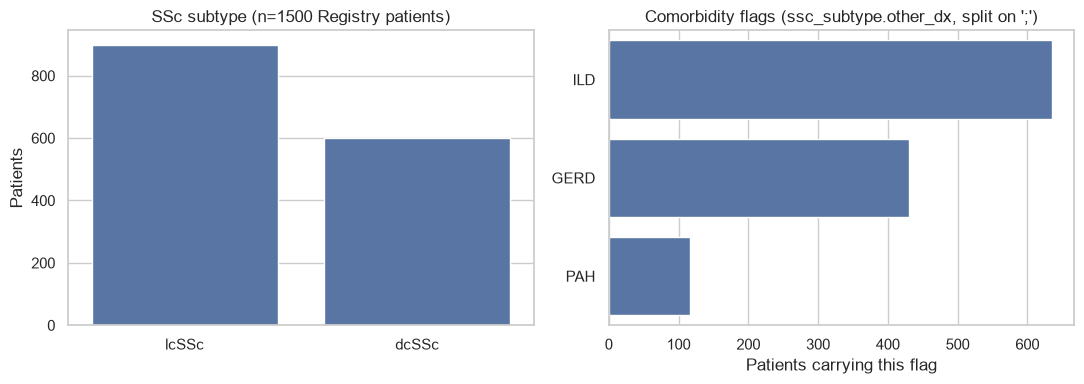

In [3]:
ssc_patients = subjects[subjects["cohort"] == "ssc_patient"]
subtype_counts = ssc_patients["ssc_subtype"].value_counts()
print(subtype_counts)

comorbidities = ssc_patients["other_dx"].dropna().str.split(";").explode().str.strip()
comorbidity_counts = comorbidities.value_counts()
print(comorbidity_counts)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(x=subtype_counts.index, y=subtype_counts.values, ax=axes[0])
axes[0].set_title(f"SSc subtype (n={len(ssc_patients)} Registry patients)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Patients")

sns.barplot(x=comorbidity_counts.values, y=comorbidity_counts.index, ax=axes[1], orient="h")
axes[1].set_title("Comorbidity flags (ssc_subtype.other_dx, split on ';')")
axes[1].set_xlabel("Patients carrying this flag")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Demographic distributions

Four categorical demographic fields, pulled one at a time through
`get_variable` (the generic field picker) rather than a bespoke query per
field. State is capped to its 10 most common values for readability — the
Registry spans far more than 10 states, long-tailed.

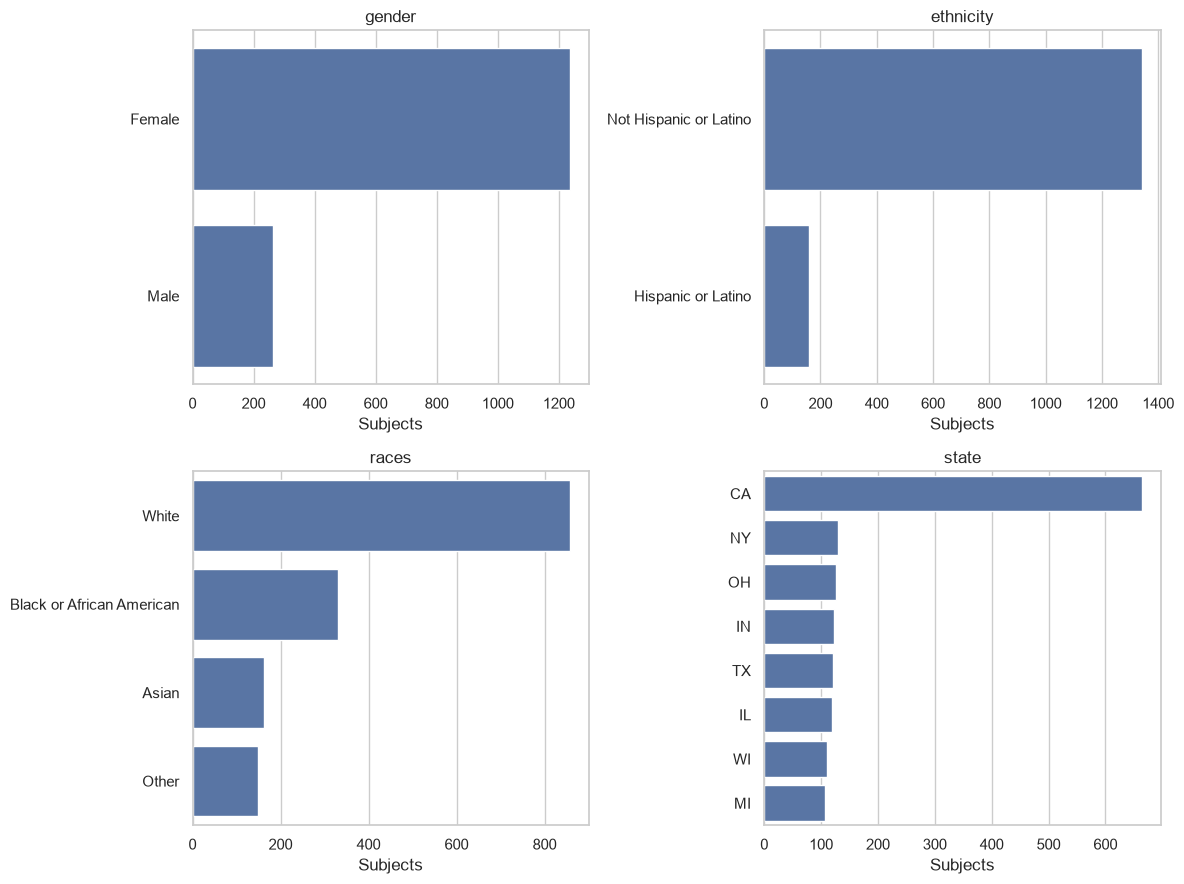

In [4]:
demographic_fields = ["gender", "ethnicity", "races", "state"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, field in zip(axes.flat, demographic_fields, strict=True):
    counts = get_variable(conn, field)["value"].dropna().value_counts()
    if len(counts) > 10:
        counts = counts.head(10)
    sns.barplot(x=counts.values, y=counts.index, ax=ax, orient="h")
    ax.set_title(field)
    ax.set_xlabel("Subjects")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

Height and weight are static, one-row-per-patient fields in `demographics`
(not longitudinal). Height is already inch-normalized here — the raw column
mixes inches and centimeters, corrected at ingestion (`data.ingest`), so no
cm-scale values leak through `get_variable`.

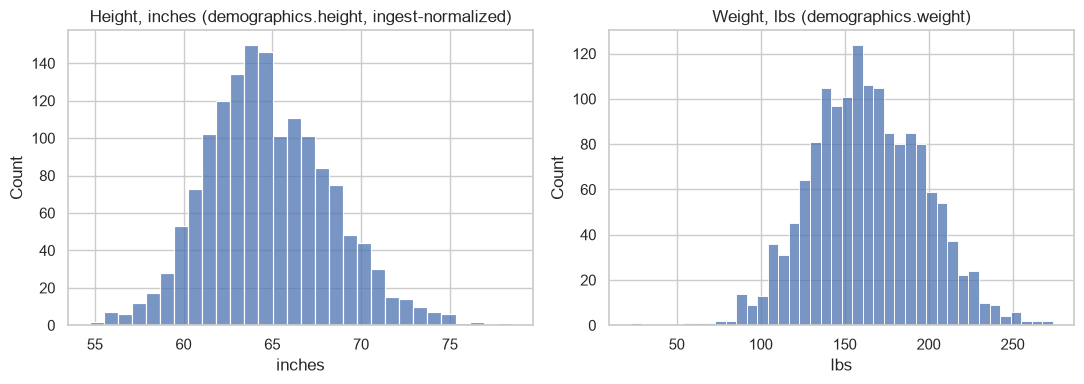

In [5]:
height = pd.to_numeric(get_variable(conn, "height")["value"], errors="coerce").dropna()
weight = pd.to_numeric(get_variable(conn, "weight")["value"], errors="coerce").dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(height, bins=30, ax=axes[0])
axes[0].set_title("Height, inches (demographics.height, ingest-normalized)")
axes[0].set_xlabel("inches")

sns.histplot(weight, bins=40, ax=axes[1])
axes[1].set_title("Weight, lbs (demographics.weight)")
axes[1].set_xlabel("lbs")
plt.tight_layout()
plt.show()

The low outlier near 0 lbs in the weight distribution is `subject_8545`'s
demographics.weight=22.5 — the corroborated data-entry error covered in the
QC report (flagged, not auto-corrected; see `docs/qc_report.md`).

## Per-table coverage and missingness

Every clinical/molecular table is a partial-coverage table of events for a
subset of the 1,504 Subjects — coverage ranges from a handful of Subjects
with a skin biopsy to nearly all of them with a vitals record.
`table_coverage` reports row count and distinct-Subject count for every
table against the full Subject population, so that gap is visible directly
rather than re-derived per table by hand.

        table  rows  distinct_subjects  subject_coverage
       vitals 40250               1503          0.999335
 demographics  1500               1500          0.997340
  ssc_subtype  1500               1500          0.997340
   antibodies  3511               1431          0.951463
  medications  3273               1327          0.882314
   lab_report 30941               1313          0.873005
          pft  5069               1174          0.780585
         mrss  3113                824          0.547872
          bal  1170                820          0.545213
    libraries   918                702          0.466755
skin_biopsies   215                150          0.099734


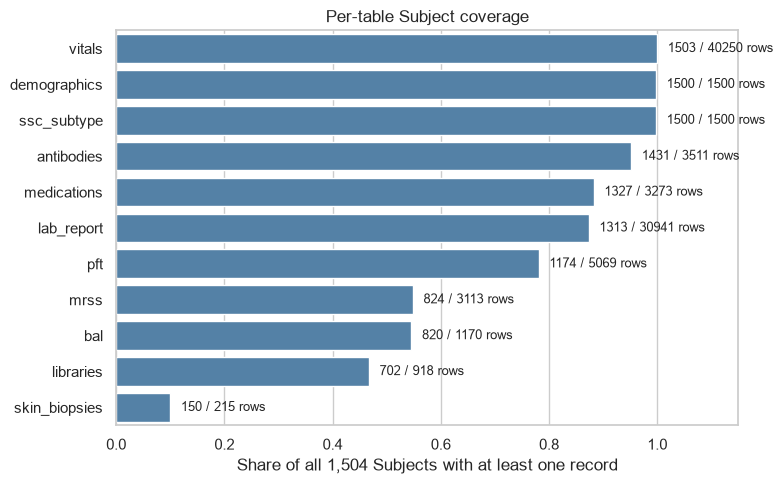

In [6]:
coverage = table_coverage(conn).sort_values("subject_coverage", ascending=False)
print(coverage.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x="subject_coverage", y="table", data=coverage, ax=ax, color="steelblue")
ax.set_xlim(0, 1.15)
ax.set_xlabel("Share of all 1,504 Subjects with at least one record")
ax.set_ylabel("")
ax.set_title("Per-table Subject coverage")
for i, (_, row) in enumerate(coverage.reset_index(drop=True).iterrows()):
    ax.text(
        row["subject_coverage"] + 0.02,
        i,
        f"{row['distinct_subjects']} / {row['rows']} rows",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

## Finding: the Control Subject cohort

Four subject IDs — `SSC_NORM_0101`, `0102`, `0104`, `0110` — never appear in
`demographics`/`ssc_subtype`, so they fall outside the Registry entirely.
The first instinct for an ID that resolves in clinical tables but not the
Registry is "orphaned record" or "join error." That's not what these are:
`libraries.csv`'s own comments describe them explicitly as "healthy control
sample" / "control sample" records, used as a comparator arm for the RNA-seq
work. The ingestion step (`data.ingest`) models this directly — every
Subject ID encountered anywhere becomes a `subjects` row, and anyone outside
the Registry is classified `cohort='control'` — rather than raising a
foreign-key error or silently dropping the rows. The QC module's key-linkage
check (`data.qc.check_key_linkage`) automates the distinction going forward:
it confirms these 4 against the known set and would flag any *future*
out-of-Registry ID that doesn't match them as genuinely unexplained.

Below, `get_subject_record` shows each Control Subject's presence across the
5 longitudinal domains the app surfaces (labs, vitals, MRSS, PFT,
medications) — confirming they're real Subjects with real records, not
placeholders. `SSC_NORM_0104` is the interesting case: it has *no* records
in any of these 5 domains. Per `libraries.csv`, its RNA-seq sample failed
QC — it exists as a Subject only because it was drawn for that molecular
work, not because it has any clinical follow-up.

In [7]:
controls = subjects[subjects["cohort"] == "control"].reset_index(drop=True)
print(controls[["subject_id", "ssc_subtype"]])

presence = pd.DataFrame(
    {
        subject_id: {
            domain: not df.empty
            for domain, df in get_subject_record(conn, subject_id)._asdict().items()
        }
        for subject_id in controls["subject_id"]
    }
).T
presence.index.name = "subject_id"
presence

      subject_id ssc_subtype
0  SSC_NORM_0101         NaN
1  SSC_NORM_0102         NaN
2  SSC_NORM_0104         NaN
3  SSC_NORM_0110         NaN


,labs,vitals,mrss,pft,medications
subject_id,,,,,
SSC_NORM_0101,False,True,True,True,False
SSC_NORM_0102,False,True,True,True,False
SSC_NORM_0104,False,False,False,False,False
SSC_NORM_0110,False,True,True,True,False


## Finding: the placeholder-weight-value finding (160.6 lbs)

`WEIGHT IN POUND` in `vitals.csv` takes the exact value 160.6 far more often
than any real measurement distribution would produce — including for the
same 3 Control Subjects who have vitals data at all. The next most common
value in this measure appears an order of magnitude less often.

8396 total WEIGHT IN POUND records
value
160.6    870
158.7     39
156.9     37
156.1     35
162.4     30
185.4     30
200.6     28
196.9     28
165.9     28
134.3     27
Name: count, dtype: int64


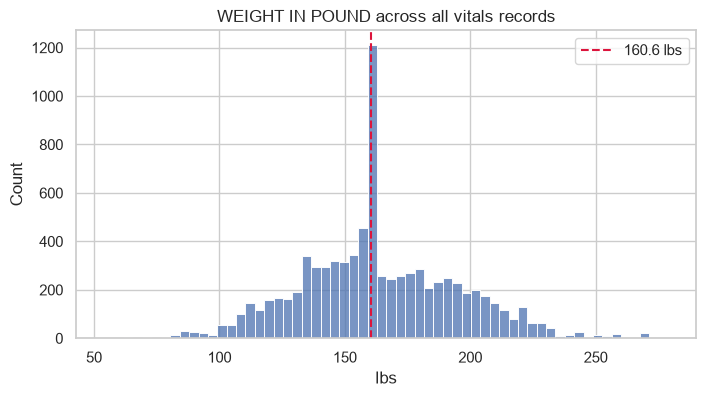

In [8]:
weight_vitals = get_variable(conn, "WEIGHT IN POUND")
print(f"{len(weight_vitals)} total WEIGHT IN POUND records")
print(weight_vitals["value"].value_counts().head(10))

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(weight_vitals["value"], bins=60, ax=ax)
ax.axvline(160.6, color="crimson", linestyle="--", label="160.6 lbs")
ax.legend()
ax.set_xlabel("lbs")
ax.set_title("WEIGHT IN POUND across all vitals records")
plt.show()

Two ways to count how many patients this affects:

- **Any occurrence** — how many patients ever recorded 160.6, on any visit.
  Computed directly from `get_variable`'s result.
- **Every-visit constant** — the stricter cut: patients for whom 160.6 is
  *every single* recorded value, across at least 2 visits. This is what
  `data.qc.check_constant_value_across_visits` reports — called here
  directly rather than re-derived by hand, so this number is guaranteed to
  match `docs/qc_report.md`, not just resemble it. A value that shows up
  once among several different real measurements isn't the same signal as
  one that never varies, which is why this cut is stricter than
  "any occurrence."

The every-visit number is necessarily smaller than the any-occurrence
number — it excludes anyone who has 160.6 mixed in among other, differing
weights.

In [9]:
any_occurrence = weight_vitals[weight_vitals["value"] == 160.6]
print(
    f"Any occurrence of 160.6: {any_occurrence['subject_id'].nunique()} patients, "
    f"{len(any_occurrence)} records"
)

# The same check that produced this line in docs/qc_report.md, called
# directly rather than re-derived — `weight_vitals` already carries a single
# measure, so it's given a constant `measure` column to satisfy the check's
# general (subject, measure) grouping shape.
for finding in check_constant_value_across_visits(
    weight_vitals.assign(measure="WEIGHT IN POUND"),
    subject_col="subject_id",
    measure_col="measure",
    value_col="value",
    table_label="vitals",
):
    print(finding)

Any occurrence of 160.6: 195 patients, 870 records
vitals: WEIGHT IN POUND is constant at 160.6 across all visits for 178 patients (848 total records) — 106x more common than expected if personal-constant values were spread evenly.


A weight that never varies across multiple years of visits isn't how real
weight measurements behave — some patients show this exact value on every
visit spanning 2017–2020. This isn't a clinical signal to explain; it reads
as a synthetic-data placeholder that the generator fell back on. The general
QC check built around this (`data.qc.check_constant_value_across_visits`)
doesn't hardcode 160.6 — a per-patient constant value is common and
unremarkable for several vitals measures (blood pressure, pulse) on its
own. What makes 160.6 stand out is that it dominates far more patients than
expected if personal-constant values were spread evenly across the values
actually observed for that measure (~106x the expected share; see
`docs/qc_report.md`). Decision: reported as an advisory QC finding, not
corrected or dropped — the underlying store is left as-delivered.

## Further reading

- Full QC findings, including the ones not repeated here as narrative
  (height-unit mixing, PFT range clipping, medication-name fragmentation,
  dose-implausibility): [`docs/qc_report.md`](../docs/qc_report.md).
- The reasoning behind every finding above: [`docs/presentation-notes.md`](../docs/presentation-notes.md).
- Domain vocabulary and architecture decisions: [`CONTEXT.md`](../CONTEXT.md), [`docs/adr/`](../docs/adr/).
- Interactive exploration of this same data (Compare & Discover, Patient
  Trajectory) lives in the Streamlit app, built on the same `data.access`
  layer used throughout this notebook.